# Calculate the metrics from the csv

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from evaluation_utils import bootstrap_from_csv
import pickle
from pathlib import Path

# --- Define models and their respective CSV paths ---
# Updated to match the folder structure generated by make_csv.py
# (Assuming this script is run from the project root)
models_to_test = {
    "DINOv2 (Video)": "csvs/dinov2_closed/closed_dist_matrix.csv",
    "DINOv2 (Image)": "csvs/dinov2_closed_image/closed_dist_matrix.csv",
    "SwinV2 (Video)": "csvs/swin_closed/closed_dist_matrix.csv",
    "SwinV2 (Image)": "csvs/swin_closed_image/closed_dist_matrix.csv",
    "ViT (Video)":    "csvs/vit_closed/closed_dist_matrix.csv",
    "ViT (Image)":    "csvs/vit_closed_image/closed_dist_matrix.csv"
}

all_results = {}

# --- Run bootstrap for each ---
for name, path in models_to_test.items():
    print(f"\n{'='*30}\nProcessing {name}\n{'='*30}")
    # Increased 'm' to 100 for statistically sound confidence intervals
    all_results[name] = bootstrap_from_csv(path, m=100, mode="closed")




Processing DINOv2 (Video)


-> Pre-calculating sorted match matrix...
-> Bootstrapping 'closed' metrics from CSV (100 iterations)...


  6%|▌         | 6/100 [00:00<00:01, 55.49it/s]

In [ ]:

# --- Save Configuration ---
SAVE_DIR = Path("results_data")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# Define a filename (e.g., "closed_world_results.pkl")
FILENAME = f"closed_world_benchmarks.pkl"
SAVE_PATH = SAVE_DIR / FILENAME

print(f"\n-> Saving all results to {SAVE_PATH}...")

with open(SAVE_PATH, 'wb') as f:
    pickle.dump(all_results, f)

print("✅ Results saved successfully.")


-> Saving all results to results_data/closed_world_benchmarks.pkl...
✅ Results saved successfully.


In [ ]:
# Load the saved data
LOAD_PATH = "results_data/closed_world_benchmarks.pkl"

with open(LOAD_PATH, 'rb') as f:
    all_results = pickle.load(f)

print(f"Loaded results for: {list(all_results.keys())}")


Loaded results for: ['DINOv2 (Video)', 'DINOv2 (Image)', 'SwinV2 (Video)', 'SwinV2 (Image)', 'ViT (Video)', 'ViT (Image)']


In [4]:
# --- Updated Print Section (Closed World) ---
print("\n" + "="*110)
print(f"{'Model':<25} | {'mAP [95% CI]':<25} | {'Rank-1 [95% CI]':<25} | {'Rank-3 [95% CI]':<25}")
print("="*110)

for name, res in all_results.items():
    # mAP with Confidence Interval
    # Note: Ensure your aggregate function saves mAP_lower/upper (see fix below)
    m_mean = res['mAP_mean']
    m_low  = res.get('mAP_lower', 0) # Fallback if not calculated
    m_high = res.get('mAP_upper', 0)
    map_str = f"{m_mean:.3f} [{m_low:.3f}-{m_high:.3f}]"
    
    # Rank-1 (Index 0)
    r1_m = res['cmc_mean'][0]
    r1_l = res['cmc_lower'][0]
    r1_u = res['cmc_upper'][0]
    r1_str = f"{r1_m:.3f} [{r1_l:.3f}-{r1_u:.3f}]"
    
    # Rank-3 (Index 2)
    idx = 2 if len(res['cmc_mean']) >= 3 else -1
    r3_m = res['cmc_mean'][idx]
    r3_l = res['cmc_lower'][idx]
    r3_u = res['cmc_upper'][idx]
    r3_str = f"{r3_m:.3f} [{r3_l:.3f}-{r3_u:.3f}]"
    
    print(f"{name:<25} | {map_str:<25} | {r1_str:<25} | {r3_str:<25}")

print("-" * 110)


Model                     | mAP [95% CI]              | Rank-1 [95% CI]           | Rank-3 [95% CI]          
DINOv2 (Video)            | 0.544 [0.522-0.570]       | 0.585 [0.555-0.610]       | 0.721 [0.692-0.746]      
DINOv2 (Image)            | 0.443 [0.421-0.462]       | 0.449 [0.419-0.470]       | 0.600 [0.577-0.628]      
SwinV2 (Video)            | 0.284 [0.263-0.303]       | 0.269 [0.238-0.292]       | 0.436 [0.406-0.465]      
SwinV2 (Image)            | 0.214 [0.199-0.228]       | 0.201 [0.182-0.219]       | 0.321 [0.297-0.341]      
ViT (Video)               | 0.307 [0.286-0.326]       | 0.313 [0.288-0.336]       | 0.462 [0.431-0.488]      
ViT (Image)               | 0.224 [0.209-0.240]       | 0.205 [0.186-0.226]       | 0.340 [0.315-0.365]      
--------------------------------------------------------------------------------------------------------------


==============================================================================================================
Model                     | mAP [95% CI]              | Rank-1 [95% CI]           | Rank-3 [95% CI]          
==============================================================================================================
DINOv2 (Video)            | 0.541 [0.516-0.563]       | 0.580 [0.553-0.604]       | 0.719 [0.694-0.743]      
DINOv2 (Image)            | 0.457 [0.436-0.475]       | 0.463 [0.440-0.488]       | 0.610 [0.584-0.636]      
SwinV2 (Video)            | 0.283 [0.262-0.301]       | 0.276 [0.243-0.302]       | 0.437 [0.405-0.463]      
SwinV2 (Image)            | 0.211 [0.197-0.224]       | 0.195 [0.175-0.211]       | 0.326 [0.299-0.347]      
ViT (Video)               | 0.307 [0.286-0.326]       | 0.313 [0.288-0.336]       | 0.462 [0.431-0.488]      
ViT (Image)               | 0.224 [0.209-0.240]       | 0.205 [0.186-0.226]       | 0.340 [0.315-0.365]      
--------------------------------------------------------------------------------------------------------------

/tmp/ipykernel_3447286/4207046457.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(all_results))


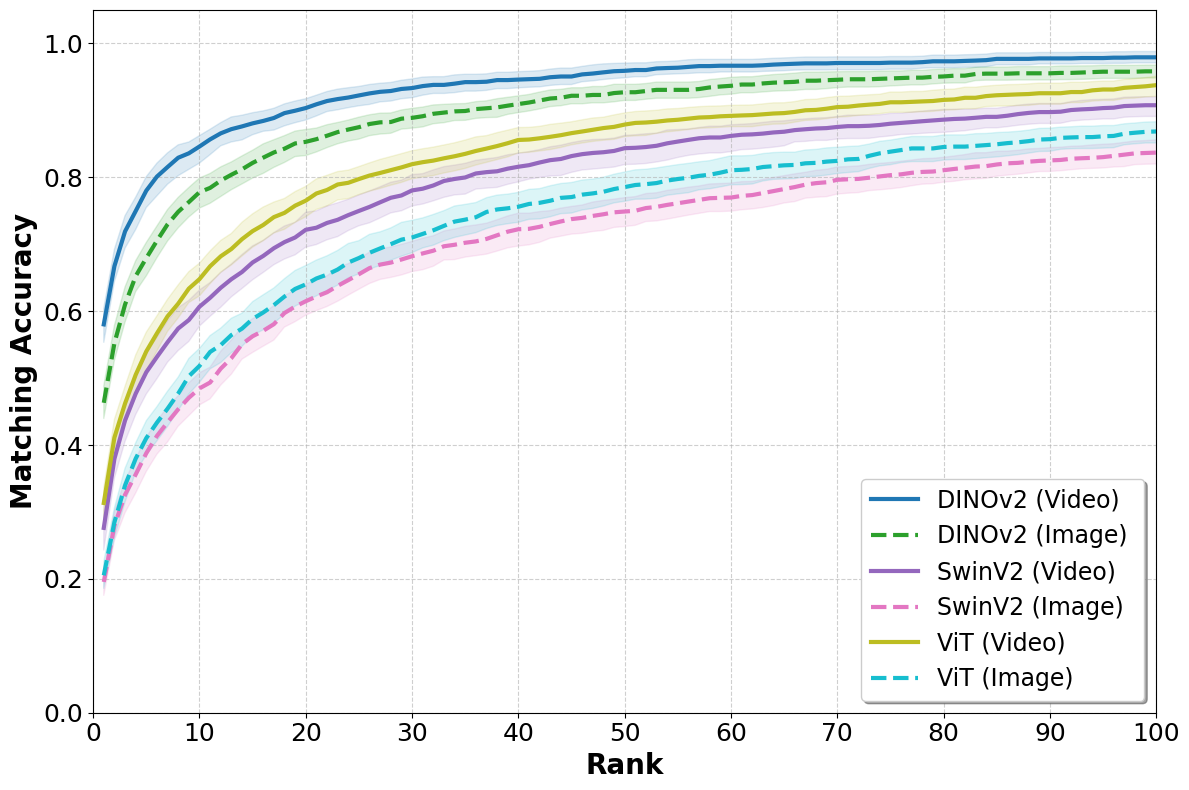

In [5]:
# -------------------------------------------------------------
# --- Plotting Configuration ---
# -------------------------------------------------------------
MAX_RANK = 100      
TICK_STEP = 10      # Increased step slightly for Rank-100 to avoid crowding
FONT_SIZE = 18        

# -------------------------------------------------------------
# --- Plotting CMC Curves with Confidence Intervals ---
# -------------------------------------------------------------

plt.figure(figsize=(12, 8))
colors = plt.cm.get_cmap('tab10', len(all_results))

for i, (name, res) in enumerate(all_results.items()):
    ranks = res["ranks"]
    cmc_mean = res["cmc_mean"]
    cmc_lower = res["cmc_lower"]
    cmc_upper = res["cmc_upper"]
    color = colors(i)
    
    # 1. Plot the Shaded Uncertainty Interval (95% CI)
    plt.fill_between(ranks, cmc_lower, cmc_upper, color=color, alpha=0.15)
    
    # 2. Plot the Mean Line
    line_style = '-' if "(Video)" in name or "(Image)" not in name else '--'
    plt.plot(ranks, cmc_mean, color=color, linestyle=line_style, linewidth=3, 
             label=f"{name} ")

# --- Format the Plot with Larger Fonts ---
plt.xlabel("Rank", fontsize=FONT_SIZE + 2, fontweight='bold')
plt.ylabel("Matching Accuracy", fontsize=FONT_SIZE + 2, fontweight='bold')

# --- Axis Tick Labels ---
plt.xticks(np.arange(0, MAX_RANK + 1, step=TICK_STEP), fontsize=FONT_SIZE)
plt.yticks(fontsize=FONT_SIZE)

# --- Dynamic Axis Control ---
plt.xlim(0, MAX_RANK) 
plt.ylim(0, 1.05)

plt.grid(True, linestyle='--', alpha=0.6)

# --- Legend Configuration ---
# Placed in lower right as CMC curves typically trend upward
plt.legend(fontsize=FONT_SIZE - 1, loc='lower right', frameon=True, shadow=True, facecolor='white')

plt.tight_layout()
plt.savefig("figs/closed_world.png")
plt.show()
